In [1]:
# Statistical Analysis and Hypothesis Testing on Heart Disease Dataset
# Using ML Models
## Course:Essential Statistics for Data Science

## Objective:To perform statistical analysis and apply hypothesis testing to identify significant factors affecting heart disease.
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score


In [14]:
pip install ucimlrepo

In [15]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [16]:
df = pd.read_csv("Heart_Disease_Prediction.csv")  # UCI dataset
df.head()
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(270, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), i

In [19]:
# Replace '?' with NaN (if present)
df.replace('?', np.nan, inplace=True)

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Handle missing values
df.fillna(df.mean(), inplace=True)

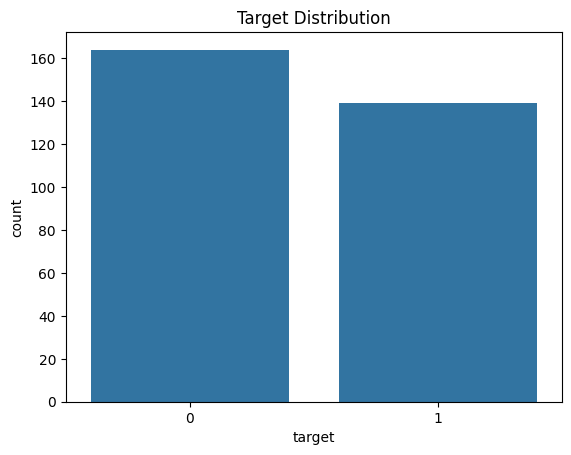

In [21]:
# Combine dataset
df = pd.concat([X, y], axis=1)

# Rename target
df.columns = list(X.columns) + ['target']

# Convert to binary
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Plot
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

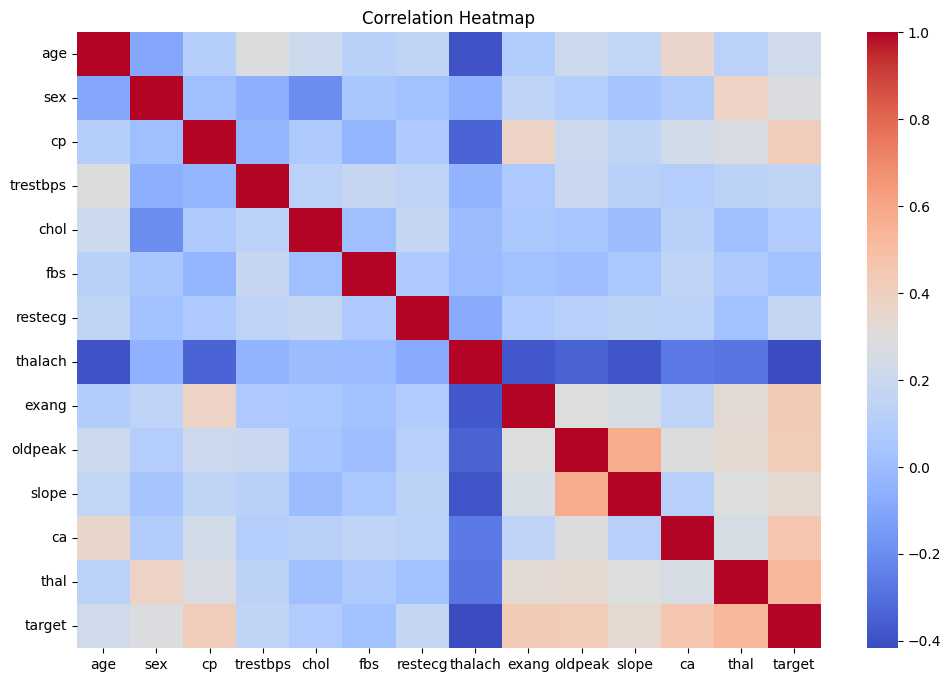

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

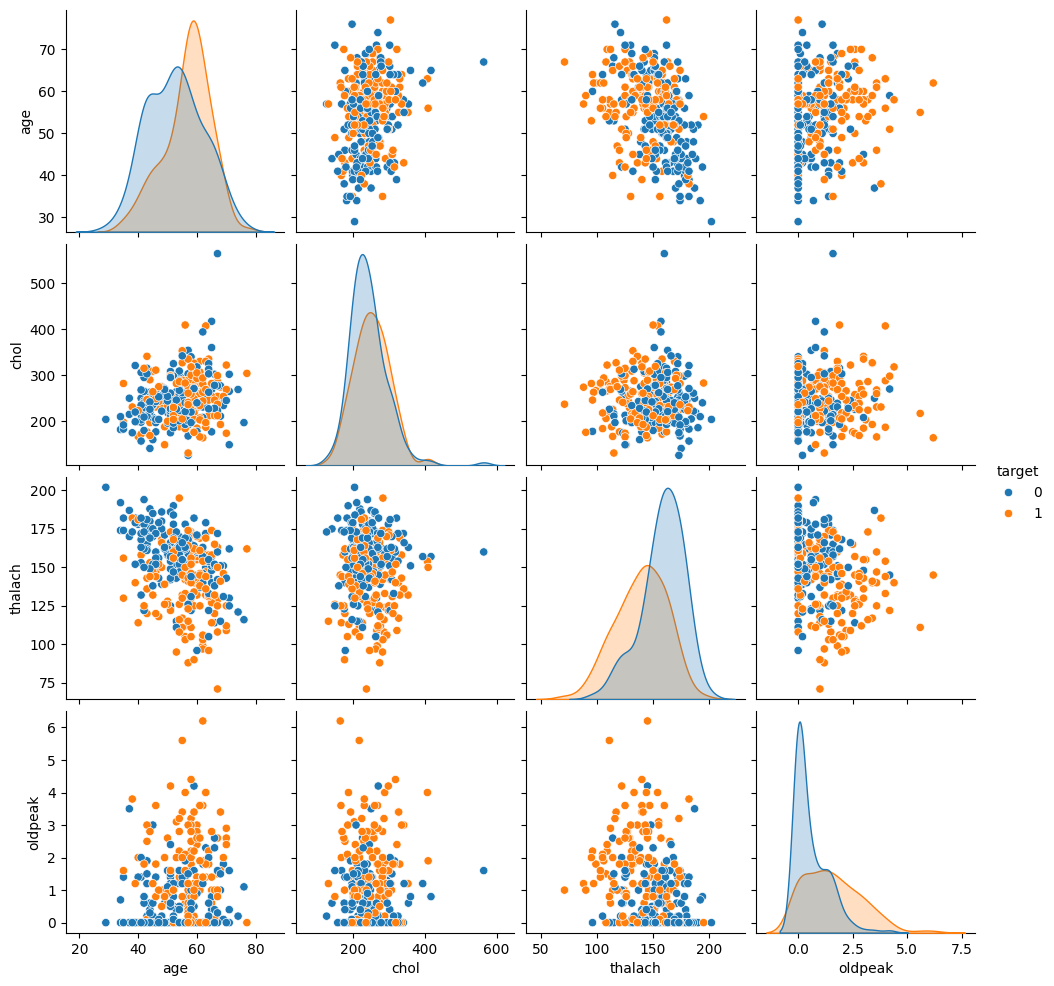

In [23]:
sns.pairplot(df[['age','chol','thalach','oldpeak','target']], hue='target')
plt.show()

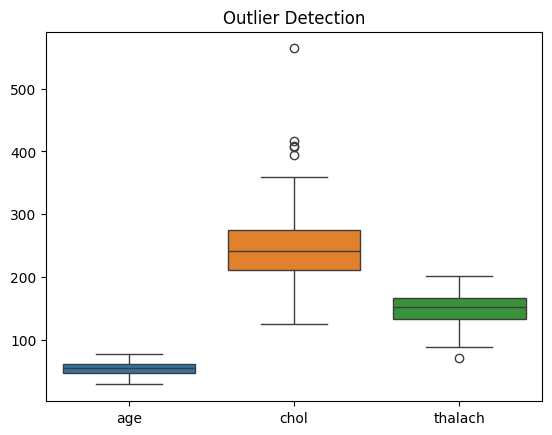

In [24]:
sns.boxplot(data=df[['age','chol','thalach']])
plt.title("Outlier Detection")
plt.show()

In [66]:
# H0: No significant relationship
# H1: Significant relationship exists

group1 = df[df['target']==0]['age']
group2 = df[df['target']==1]['age']

t_stat, p_val = stats.ttest_ind(group1, group2)

print("T-Test (Age vs Target)")
print("T-statistic:", t_stat)
print("p-value:", p_val)

alpha = 0.05

if p_val < alpha:
    print("Reject H0 → Age significantly affects heart disease")
else:
    print("Fail to reject H0 → No significant effect")

T-Test (Age vs Target)
T-statistic: -3.971100226293655
p-value: 8.955636917529706e-05
Reject H0 → Age significantly affects heart disease


In [67]:
# H0: No significant relationship
# H1: Significant relationship exists

cont_table = pd.crosstab(df['sex'], df['target'])

chi2, p, dof, exp = stats.chi2_contingency(cont_table)

print("\nChi-Square Test (Sex vs Target)")
print("Chi2:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 → Significant association exists")
else:
    print("Fail to reject H0 → No association")


Chi-Square Test (Sex vs Target)
Chi2: 22.042560606155472
p-value: 2.666712348180942e-06
Reject H0 → Significant association exists


In [68]:
# H0: No significant relationship
# H1: Significant relationship exists

groups = [df[df['cp']==i]['target'] for i in df['cp'].unique()]

f_stat, p_val = stats.f_oneway(*groups)

print("\nANOVA Test (cp vs Target)")
print("F-statistic:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H0 → Significant difference between groups")
else:
    print("Fail to reject H0 → No significant difference")


ANOVA Test (cp vs Target)
F-statistic: 36.86657549872937
p-value: 2.6636869889023695e-20
Reject H0 → Significant difference between groups


In [54]:
corr = df.corr()['target'].sort_values(ascending=False)

print("\nCorrelation with Target:")
print(corr)


Correlation with Target:
target      1.000000
thal        0.523928
ca          0.457598
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [55]:
from statsmodels.stats.weightstats import ztest

z_stat, p_val = ztest(group1, group2)

print("\nZ-Test")
print("Z-stat:", z_stat)
print("p-value:", p_val)


Z-Test
Z-stat: -3.971100226293655
p-value: 7.154147177675878e-05


In [56]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values with mean
df.fillna(df.mean(), inplace=True)

# Verify
print("Remaining NaN:\n", df.isnull().sum())

Remaining NaN:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

Accuracy: 0.8852459016393442


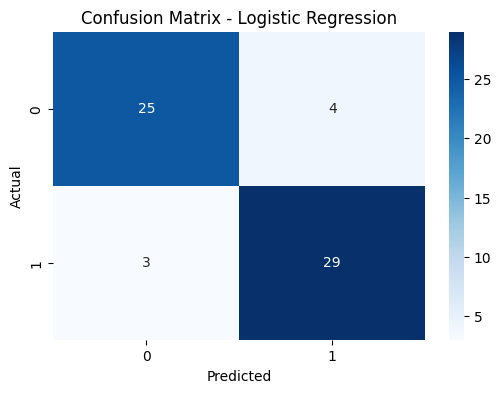

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.93      0.89        29
           1       0.93      0.84      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Accuracy: 0.8852459016393442


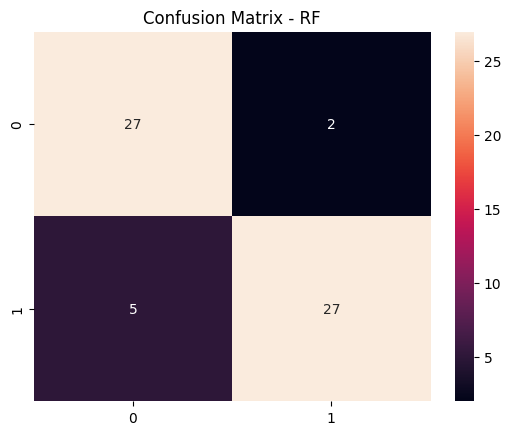

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - RF")
plt.show()

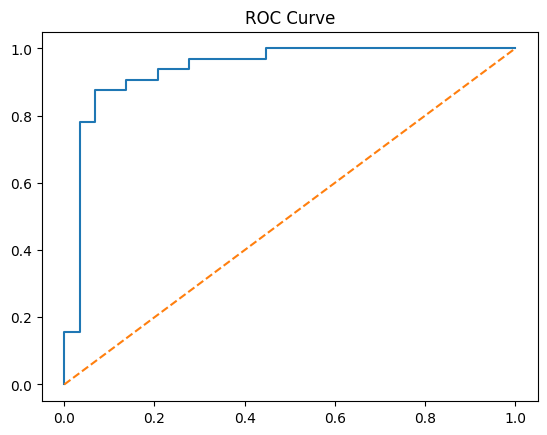

AUC: 0.9385775862068966


In [45]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_prob))

In [69]:
print("Cross-validation scores:", cv)
print("Mean CV score:", cv.mean())

Cross-validation scores: [0.86885246 0.90163934 0.81967213 0.73333333 0.78333333]
Mean CV score: 0.8213661202185791


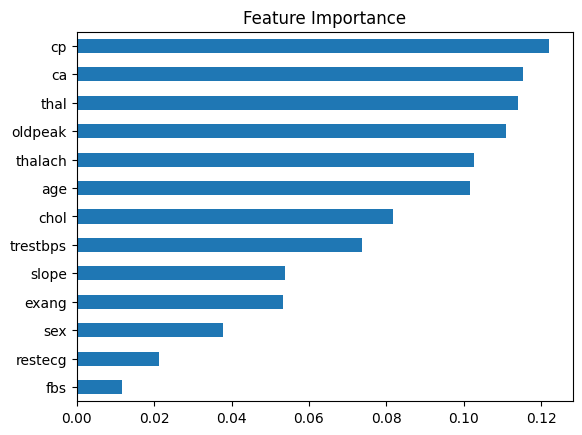

In [70]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [47]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[None,10,20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 100}


In [48]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.885246
1        Random Forest  0.885246


In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

# Random Forest metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# ROC AUC
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# Create DataFrame
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "Precision": [lr_prec, rf_prec],
    "Recall": [lr_rec, rf_rec],
    "F1 Score": [lr_f1, rf_f1],
    "ROC-AUC": [lr_auc, rf_auc]
})

print(comparison)

                 Model  Accuracy  Precision   Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.885246   0.878788  0.90625  0.892308  0.919181
1        Random Forest  0.885246   0.931034  0.84375  0.885246  0.938578


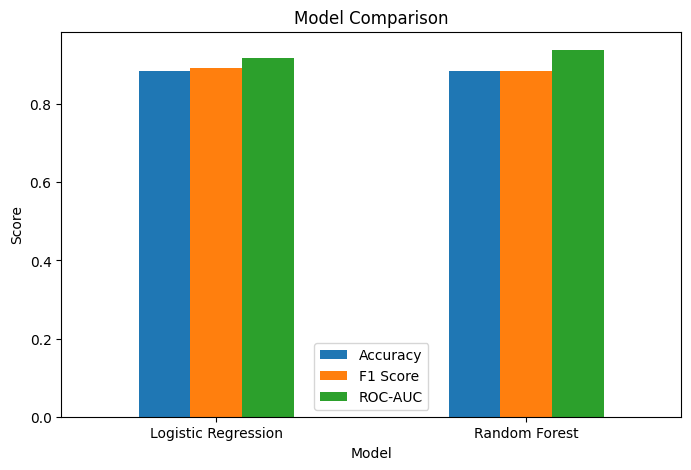

In [65]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["Accuracy","F1 Score","ROC-AUC"]].plot(
    kind='bar', figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()